# Clasificación de vinos con redes neuronales



In [385]:
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import random
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from joblib import Parallel, delayed

In [386]:
class MLPChromosome_genotype:
    def __init__(self, hidden_layer_sizes = None, binary_representation = None, layers_switch=None, n_features=0):
        #creamos la codificacion binaria del cromosoma
        if hidden_layer_sizes is not None and binary_representation is None:
            self.binary_representation = self._encode(hidden_layer_sizes,layers_switch)
        elif hidden_layer_sizes is None and binary_representation is not None:
            self.binary_representation = binary_representation
        
        self.fitness = None
        # este parámetro va a controlar dónde empieza la codificación de la arquitectura.
        # Si el cromosoma no codifica features, entonces n_features=0 y la codificación de la arquitectur comienza desde el primer bit
        self.n_features = n_features

    def _encode(self, hidden_layer_sizes, feature_mask=None, layers_switch=None):
        if layers_switch is None:
            layers_switch = ["1", "1"]
        
        """Codifica las soluciones como bits"""
        n_1 = hidden_layer_sizes[0]
        n_2 = hidden_layer_sizes[1]
        n_3 = hidden_layer_sizes[2]
        
        #losconvierto a binarios en 7 bits
        bin_1 = format(n_1 - 1, "07b")
        bin_2 = format(n_2 - 1, "07b")
        bin_3 = format(n_3 - 1, "07b")

        # asumo por defecto que estan activas las capas
        a2 = layers_switch[0]
        a3 = layers_switch[1]

        chromosome = bin_1 + a2 + bin_2 + a3 + bin_3
        
        if feature_mask is not None:
            #binario de n bits para la codificación de las features (n=cantidad de features)
            bin_f = "".join(str(b) for b in feature_mask)
            chromosome = bin_f + chromosome
        
        return chromosome
    
    def decode(self):
        chromosome = self.binary_representation
        #a partir de este indice empieza la codificación de las capas: [cod_features | cod_capas] donde "|" <- base index
        base_layers_index = self.n_features

        layer1_bits = chromosome[base_layers_index:base_layers_index+7]
        h1 = int(layer1_bits, 2) + 1

        a2 = chromosome[base_layers_index+7]

        if a2 == "1":
            layer2_bits = chromosome[base_layers_index+8:base_layers_index+15]
            h2 = int(layer2_bits, 2) + 1
        else:
            h2 = None

        a3 = chromosome[base_layers_index+15]

        if a3 == "1":
            layer3_bits = chromosome[base_layers_index+16:base_layers_index+23]
            h3 = int(layer3_bits, 2) + 1
        else:
            h3 = None
        
        f = chromosome[0:base_layers_index]
        
        return (h1, h2, h3), f

    # def mutate(self):
    #     """
    #     Cambia un bit al azar de la representacion binaria del cromosoma
    #     Puede cambiar bits de activacion o no
    #     """

    #     chromosome = list(self.binary_representation)

    #     idx = random.randint(0, len(chromosome)-1)

    #     chromosome[idx] = (
    #         "1" if chromosome[idx] == "0" else "0"
    #     )

    #     self.binary_representation = "".join(chromosome)
    
    #El enunicado habla de pm por bit, no por cromosoma
    def mutate(self, pm=0.01):
        chromosome = list(self.binary_representation)
        for i in range(len(chromosome)):
            if random.random() < pm:
                chromosome[i] = "1" if chromosome[i] == "0" else "0"
        self.binary_representation = "".join(chromosome)
        
        self.fix()
        
    #Corrige el cromosoma si este apaga todas las features (la corrección consiste en prender una aleatoria)
    def fix(self):
        # n_features = 0 significa que no estamos codificando las features, por ende no hay nada para corregir
        if self.n_features == 0: return
        
        chromosome = list(self.binary_representation)
        features_cod = self.chromosome[0:n_features]
        if np.sum(features_cod) == 0:
            random_idx = np.random.randint(0,n_features)
            chromosome[random_idx] = "1"
            self.binary_representation = "".join(chromosome)
        

    def __repr__(self):
        return f"Chromosome({self.binary_representation})"
    
    def __len__(self):
        return len(self.binary_representation)

In [387]:
# ejercicio 


df_wine = load_wine(as_frame=True)

X = df_wine.data
y = df_wine.target


In [388]:
display(X.describe())
display(X.info())
display(X.nunique()) #para ver categoricas
display(y.value_counts())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

None

alcohol                         126
malic_acid                      133
ash                              79
alcalinity_of_ash                63
magnesium                        53
total_phenols                    97
flavanoids                      132
nonflavanoid_phenols             39
proanthocyanins                 101
color_intensity                 132
hue                              78
od280/od315_of_diluted_wines    122
proline                         121
dtype: int64

target
1    71
0    59
2    48
Name: count, dtype: int64

In [389]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
s = scaler.fit(X_train)
X_train_scaled = s.transform(X_train)
X_test_scaled = s.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes = (16,8),
    activation = 'tanh',
    solver = 'sgd',
    max_iter = 300,
    learning_rate_init = 0.01,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)



 accuracy: 0.9777777777777777


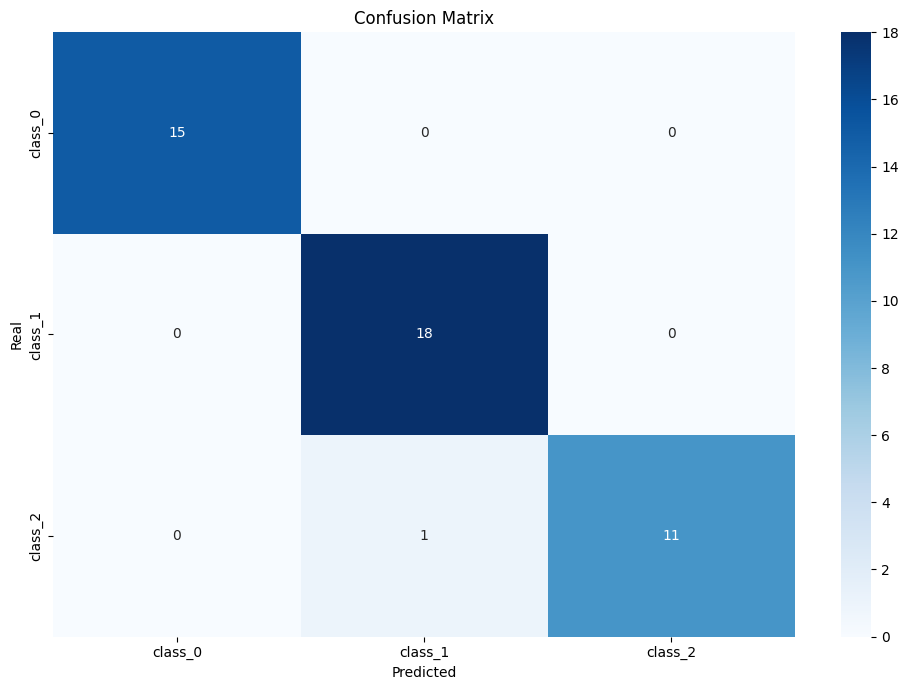

In [390]:
acc_ref_model = model.score(X_test_scaled, y_test)
print(f" accuracy: {acc_ref_model}")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot = True, fmt= 'd', cmap = 'Blues',
            xticklabels = df_wine.target_names,
            yticklabels = df_wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


La cantidad de parametros optimizablesson:
- hidden_layers [16, 8]
- n_clases = 3
- n_features(imputs de la capa de entrada) = 13

entonces:
- Params capa 1: 13 * 16 + 16 (bias para cada neurona) = 208
- Params capa 2: 16 (salidas de capa 1) * 8 + 8 = 136
- Params capa 3: 8 (salidas de capa 2) * 3 (cantidad de clases) + 3 = 27

resultado = 224 + 136 + 27 = 387

# Ejercicio 2: Optimizacion de la arquitectura mediante algoritmo geneticos
Considerando hasta 3 capas ocultas. Buscar arquitectura que maximice el accuracy de validacion.
Complejidad es el numero de parámetros entrenables

Usamos N=13 atributos del datasets, solo optimizaremos la cantidad de parmetros (reduciendo la cantidad de capas)

**Representacion del cromosoma:**

Cada individuo de la poblacion representa una arquitectura (posible solucion).
- La primera capa esta siempre activa: su bit de activacion no forma parte del cromosoma y sus 7 bits codifican en binario sin signo el numero de neuronas de la capa
- Para la capa 2 y 3 el primer bit implica la activación o no de la capa. El resto de bits representa la cantidad de neuronas

**Funcion de aptitud**
Se deseará optimizar el accuracy promedio en una validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamienot.



In [391]:
# ahora programamos la clase para el algoritmo genetico

class genetic_algorithm:
    def __init__(self, model_selection, model_cross, model_init):
        if model_selection == "ranking":
            self.f_selection = self._ranking
        elif  model_selection == "tournament":
            self.f_selection = self._tournament
        else: 
            raise ValueError("no")

        if model_cross == "unique":
            self.f_cross = self._unique_cross

        if model_init == "random":
            self.f_init = self._random_init
        
        self.population = []
        self.generational_fitness = {
            "best": [],
            "avg": []
        }
        
    

    def run(self, n_init, p_cross, p_mutate,X_train, y_train, max_iters, beta):
        self.alpha = 1 - beta
        self.beta = beta
        # inicializamos la poblacion
        self.population = self.f_init(n_init)

        for chromosome in self.population:
            chromosome.fitness = self.fitness(chromosome, X_train, y_train)
        
        for generation in range(max_iters):
            #Aplicamos elitismo (en cada generación, conservamos el mejor individuo de la anterior)
            best_chromosome = max(self.population, key=lambda chromosome: chromosome.fitness)
            new_population = [best_chromosome]

            while len(new_population)< len(self.population):
                parent_1 = self.f_selection()
                parent_2 = self.f_selection()

                if random.random()<p_cross:
                    child_1, child_2 = self.f_cross(parent_1, parent_2)
                else:
                    #dejamos los padres
                    child_1 = MLPChromosome_genotype(binary_representation = parent_1.binary_representation)
                    child_2 = MLPChromosome_genotype(binary_representation = parent_2.binary_representation)
                
                #una vez tenido los hijos mutamos y corregimos
                # if random.random() < p_mutate:
                #     child_1.mutate()
                
                # if random.random() < p_mutate:
                #     child_2.mutate()
                
                child_1.mutate(pm=p_mutate)
                child_2.mutate(pm=p_mutate)
                
                child_1.fitness = self.fitness(child_1, X_train, y_train)

                new_population.append(child_1)
                if len(new_population) < len(self.population):
                    child_2.fitness = self.fitness(child_2, X_train, y_train)
                    new_population.append(child_2) #por si la poblacion es impar

                # recalculamos fitness de toda la nueva poblacion

            # for chromosome in new_population:
            #     chromosome.fitness = self.fitness(
            #         chromosome,
            #         X_train,
            #         y_train
            #     )

            gen_fitness = [chromosome.fitness for chromosome in new_population]
            avg_fitness = np.mean(gen_fitness)
            max_fitness = np.max(gen_fitness)
            # guardamos historial
            self.generational_fitness["best"].append(max_fitness)
            self.generational_fitness["avg"].append(avg_fitness)
            #reemplazo generacional a priori
            self.population = new_population
        best_chromosome = max(self.population, key=lambda chromosome: chromosome.fitness)

        return best_chromosome

    def fitness(self, chromosome, X_train, y_train, max_params = 35203):
        layers, _ = chromosome.decode()

        #eliminar capas Nones
        hidden_layers = tuple(layer for layer in layers if layer is not None)

        model = MLPClassifier(hidden_layer_sizes = hidden_layers, max_iter = 300, early_stopping = True, random_state = 42, n_iter_no_change = 10, validation_fraction = 0.1)
        cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)
        scores = cross_val_score(model, X_train, y_train, cv = cv, scoring = "accuracy")

        accuracy_cv = np.mean(scores)
        input_dim = X_train.shape[1]
        output_dim = len(np.unique(y_train))

        architecture = [input_dim] + list(hidden_layers) + [output_dim] #lista con todo
        n_params =0

        for i in range(len(architecture)-1):
            n_in = architecture[i]
            n_out = architecture[i+1]
            # pesos + bias
            n_params += (n_in + 1) * n_out

        compactness = 1 - (n_params / max_params)
        fit = self.alpha * accuracy_cv + self.beta *compactness

        return fit

    def _tournament(self, k=3):
        candidates = random.sample(self.population, k)
        winner = max(candidates,key=lambda chromosome: chromosome.fitness)

        return winner

    def _ranking(self):
        pass

    def _unique_cross(self, parent_1, parent_2):
    
        p1 = parent_1.binary_representation
        p2 = parent_2.binary_representation

        layer1_p1 = p1[0:7]
        layer1_p2 = p2[0:7]

        child1_layer1 = layer1_p1[:3] + layer1_p2[3:]
        child2_layer1 = layer1_p2[:3] + layer1_p1[3:]

        a2_child1 = p1[7] #conservamos del padre "principal"
        a2_child2 = p2[7]

        layer2_p1 = p1[8:15]
        layer2_p2 = p2[8:15]

        child1_layer2 = layer2_p1[:3] + layer2_p2[3:]
        child2_layer2 = layer2_p2[:3] + layer2_p1[3:]

        a3_child1 = p1[15]
        a3_child2 = p2[15]

        layer3_p1 = p1[16:23]
        layer3_p2 = p2[16:23]

        child1_layer3 = layer3_p1[:3] + layer3_p2[3:]
        child2_layer3 = layer3_p2[:3] + layer3_p1[3:]

        
        child1_bits = (child1_layer1 + a2_child1 + child1_layer2 + a3_child1 + child1_layer3) #hijo 1
        child2_bits = (child2_layer1 + a2_child2 + child2_layer2 +a3_child2 + child2_layer3) #hijo 2

        child1 = MLPChromosome_genotype(binary_representation=child1_bits)
        child2 = MLPChromosome_genotype(binary_representation=child2_bits)
        return child1, child2

    def _random_init(self, n_init):
        self.population = []
        for _ in range(n_init):  
            h1 = random.randint(1, 128)
            h2 = random.randint(1, 128)
            h3 = random.randint(1, 128)
            
            a2 = "1" if np.random.random() >= 0.5 else "0"
            a3 = "1" if np.random.random() >= 0.5 else "0"

            chromosome = MLPChromosome_genotype(hidden_layer_sizes=(h1, h2, h3), layers_switch=[a2,a3])
            self.population.append(chromosome)
        return self.population



# ejercicio 2:


In [ ]:
betas = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]

def run_ga_for_beta(beta):
    ga = genetic_algorithm(
        model_selection="tournament",
        model_cross="unique",
        model_init="random"
    )
    best_chromosome = ga.run(
        n_init=10,
        p_cross=0.8,
        p_mutate=0.01,
        X_train=X_train_scaled,
        y_train=y_train,
        max_iters=50,
        beta=beta
    )
    return beta, {
        "fitness_history": ga.generational_fitness,
        "best_chromosome": best_chromosome,
        "best_fitness": best_chromosome.fitness
    }

outputs = Parallel(n_jobs=-1)(delayed(run_ga_for_beta)(b) for b in betas)
results = dict(outputs)

best_global_beta, best_global_chromosome = max(
    ((b, results[b]["best_chromosome"]) for b in betas),
    key=lambda x: x[1].fitness
)
best_global_fitness = best_global_chromosome.fitness


In [393]:
# for key, values in results.items():
#     print("="*50)
#     print(f"Beta = {key}:")
#     print(f"Mejor cromosoma: {values['best_chromosome']}")
#     print(f"Arquitectura:    {values['best_chromosome'].decode()}")
#     print(f"Mejor fitness:   {values['best_fitness']:.4f}")

# print("\n" + "="*50)
# print("MEJOR SOLUCION GLOBAL")
# print("="*50)
# print(f"Beta:        {best_global_beta}")
# print(f"Cromosoma:   {best_global_chromosome}")
# print(f"Arquitectura:{best_global_chromosome.decode()}")
# print(f"Fitness:     {best_global_fitness:.4f}")

# best_history = results[best_global_beta]["fitness_history"]["best"]
# plt.figure(figsize=(10,6))
# plt.plot(best_history)
# plt.xlabel("Generacion")
# plt.ylabel("Fitness promedio")
# plt.title(f"Evolucion del Fitness Generacional\nMejor beta = {best_global_beta}")
# plt.grid(True)
# plt.show()


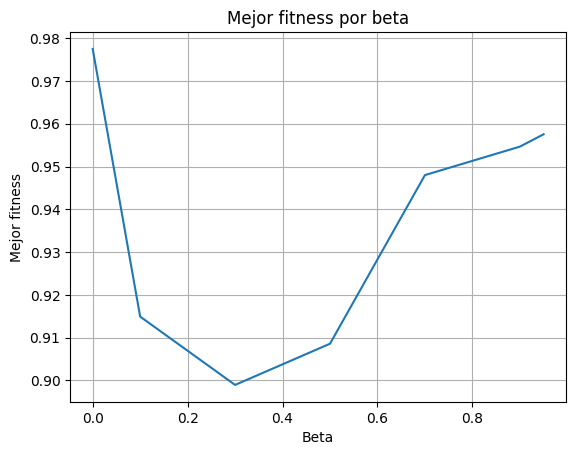

In [394]:
#Fitness del mejor individuo de la última generación, por beta
best_fitness_by_beta = [results[key]["best_fitness"] for key in results.keys()]

sns.lineplot(x=results.keys(), y=best_fitness_by_beta)
plt.title("Mejor fitness por beta")
plt.xlabel("Beta")
plt.ylabel("Mejor fitness")
plt.grid(True)

In [395]:
# # decodificamos arquitectura del mejor individuo

# layers = best_global_chromosome.decode()

# hidden_layers = tuple(
#     layer for layer in layers
#     if layer is not None
# )

# print(hidden_layers)

# scaler = StandardScaler()
# scaler.fit(X)
# X_scaled = scaler.transform(X)


# final_model = MLPClassifier(
#     hidden_layer_sizes=hidden_layers,
#     max_iter=300,
#     early_stopping=True,
#     random_state=42
# )

# final_model.fit(X_scaled, y)

Grafique la evolución del mejor fitness y del fitness promedio de la población a lo largo de las
generaciones.

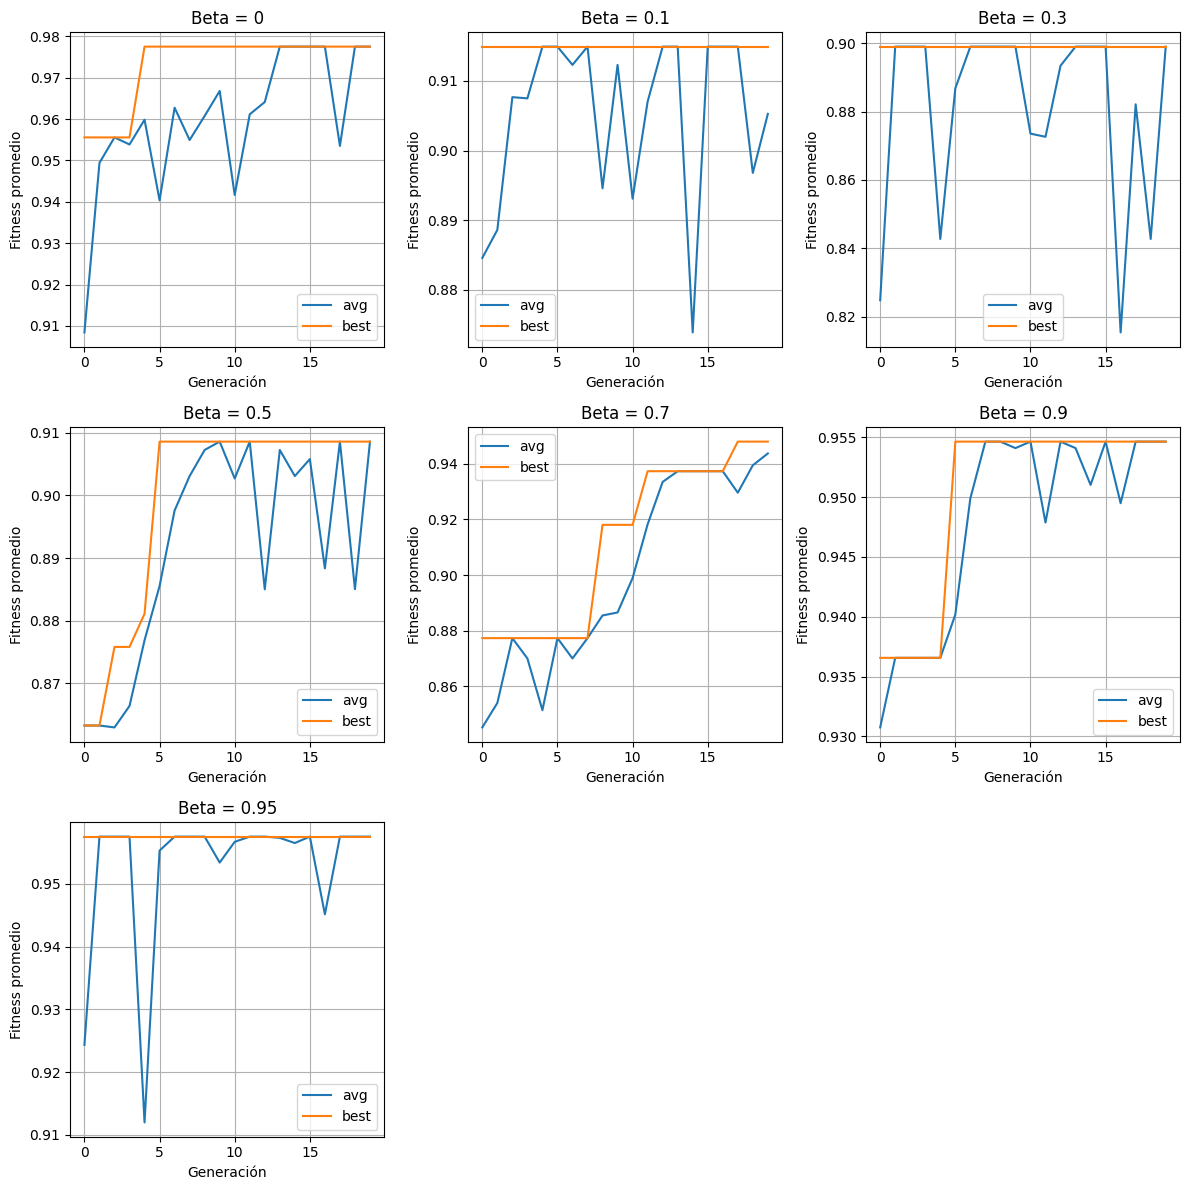

In [396]:
n = len(betas)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for ax, (beta, data) in zip(axes, results.items()):
    ax.plot(data["fitness_history"]["avg"], label="avg")
    ax.plot(data["fitness_history"]["best"], label="best")
    ax.set_title(f"Beta = {beta}")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Fitness promedio")
    ax.grid(True)
    ax.legend()

for ax in axes[n:]:  # ocultar subplots vacíos si n < rows*cols
    ax.set_visible(False)

plt.tight_layout()
plt.show()


Identifique el mejor individuo de la última generación, decodifique su cromosoma e informe la
arquitectura encontrada.

In [397]:
best_archs = []

for beta, data in results.items():
    print("="*50)
    print(f"Beta: {beta}")
    arch, _ = data["best_chromosome"].decode()
    best_archs.append(arch)
    print(f"Mejor arquitctura: {arch}")

Beta: 0
Mejor arquitctura: (87, 125, 59)
Beta: 0.1
Mejor arquitctura: (89, 49, 99)
Beta: 0.3
Mejor arquitctura: (82, None, None)
Beta: 0.5
Mejor arquitctura: (33, None, 76)
Beta: 0.7
Mejor arquitctura: (73, None, None)
Beta: 0.9
Mejor arquitctura: (51, None, None)
Beta: 0.95
Mejor arquitctura: (72, None, None)


Entrene el modelo con esa arquitectura sobre el conjunto de entrenamiento completo y reporte
su accuracy y la matriz de confusión sobre el conjunto de prueba. Analice la matriz: ¿qué pares
de clases concentran la mayor cantidad de errores? ¿El error es simétrico entre clases o hay
direcciones de confusión predominantes?

In [398]:
cms = []
accuracies = []

for beta, data in results.items():
    print("="*50)
    print(f"Beta: {beta}")
    layers, _ = data["best_chromosome"].decode()
    
    hidden_layers = tuple(layer for layer in layers if layer is not None)

    final_model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        max_iter=300,
        random_state=42,
        activation='tanh',     
        solver='sgd',           
        learning_rate_init=0.01, 
    )

    final_model.fit(X_train_scaled, y_train)
    y_pred = final_model.predict(X_test_scaled)
    
    accuracy = final_model.score(X_test_scaled, y_test)
    print(f"arquitectura: {hidden_layers}")
    print(f" accuracy: {accuracy}")
    
    cms.append(confusion_matrix(y_test, y_pred))
    accuracies.append(accuracy)

        

Beta: 0
arquitectura: (87, 125, 59)
 accuracy: 0.9777777777777777
Beta: 0.1
arquitectura: (89, 49, 99)
 accuracy: 0.9777777777777777
Beta: 0.3
arquitectura: (82,)
 accuracy: 1.0
Beta: 0.5
arquitectura: (33, 76)
 accuracy: 0.9777777777777777
Beta: 0.7
arquitectura: (73,)
 accuracy: 1.0
Beta: 0.9
arquitectura: (51,)
 accuracy: 1.0
Beta: 0.95
arquitectura: (72,)
 accuracy: 0.9777777777777777


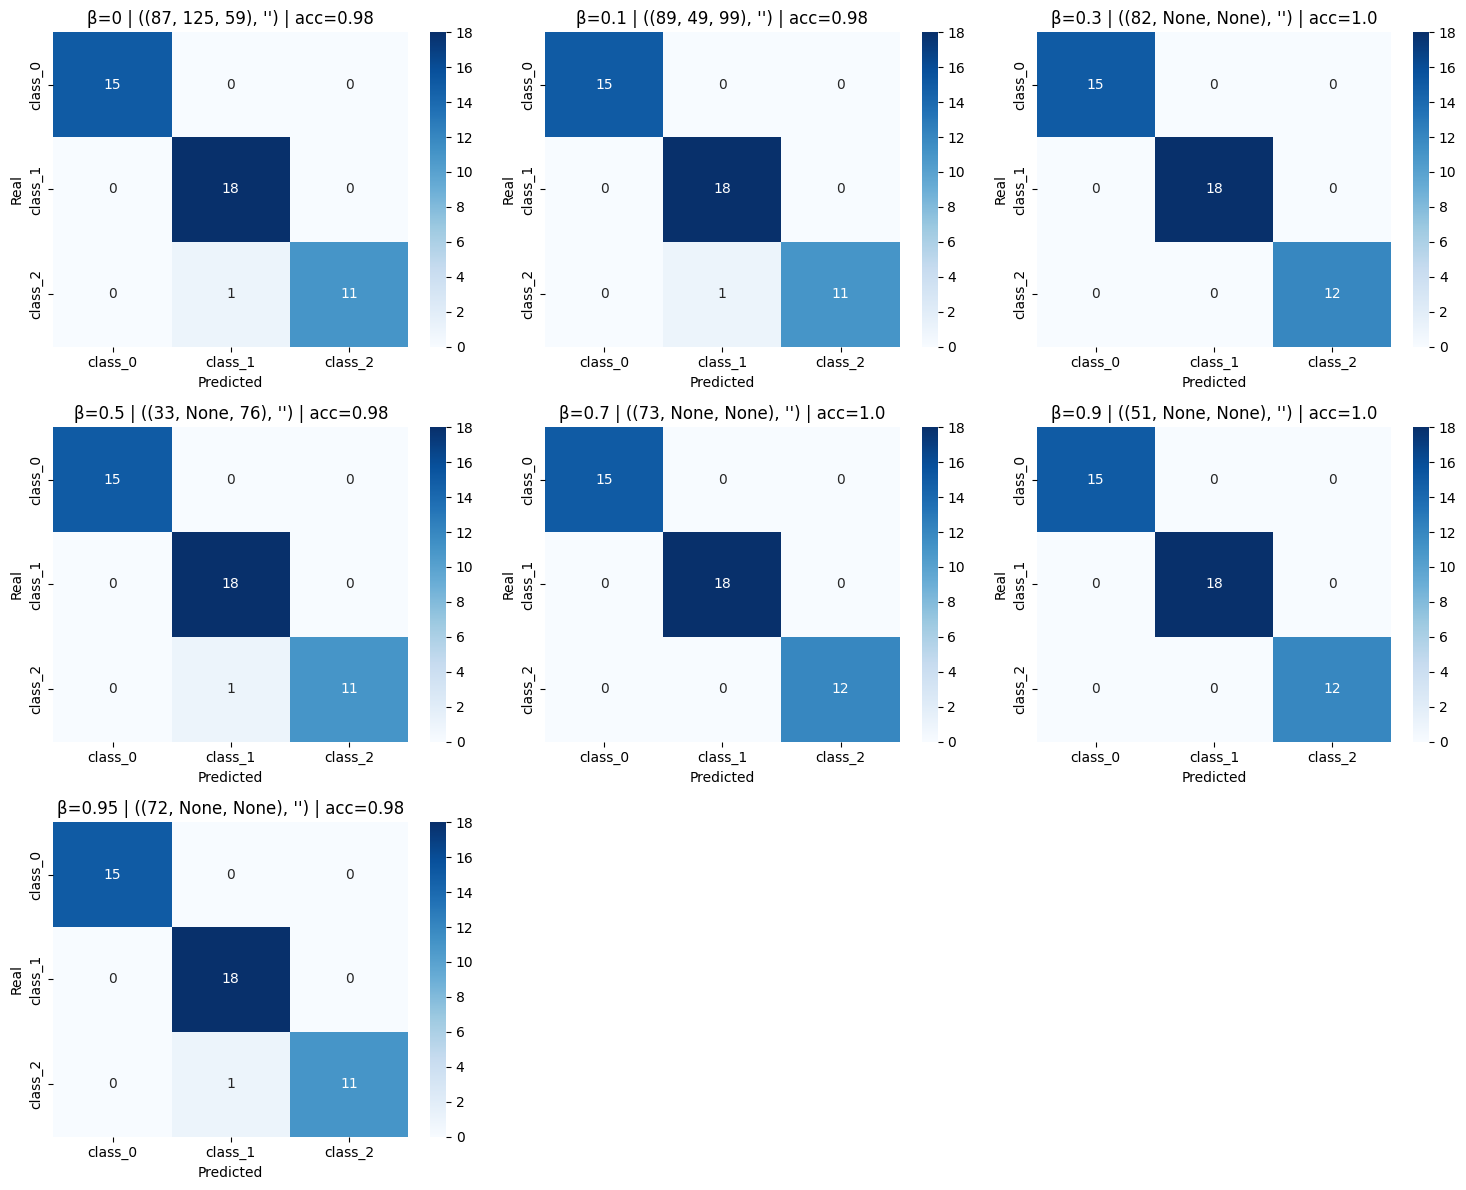

In [399]:
n = len(results)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for ax, (beta, data), cm, acc in zip(axes, results.items(), cms, accuracies):
    hidden_layers = tuple(
        layer for layer in data["best_chromosome"].decode()
        if layer is not None
    )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=df_wine.target_names,
                yticklabels=df_wine.target_names)
    ax.set_title(f"β={beta} | {hidden_layers} | acc={round(acc,2)}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Real")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


Calcule la cantidad total de parámetros P(I) del mejor modelo y compárela con la del modelo
de referencia del Ejercicio 1 de la Sección 1.

In [400]:
def count_parameters(layers, inputs=13, outputs=3):
    total = 0
    for i, layer in enumerate(layers):
        if i == 0:
            total += (inputs + 1) * layer
        else:
            total += (layers[i-1] + 1) * layer
    total += (layers[-1] + 1) * outputs
    return total

In [401]:
print(f"REFERENCIA: 387 parámetros - acc: {np.round(acc_ref_model,2)}")
print("\n")

params = []

for arch, acc in zip(best_archs,accuracies):
    hidden_layers = tuple(layer for layer in arch if layer is not None)
    arch_params = count_parameters(hidden_layers)
    params.append(arch_params)
    
    print(f"hl: {arch}, acc: {np.round(acc,2)}, params: {arch_params}")

REFERENCIA: 387 parámetros - acc: 0.98


hl: (87, 125, 59), acc: 0.98, params: 19832
hl: (89, 49, 99), acc: 0.98, params: 10906
hl: (82, None, None), acc: 1.0, params: 1397
hl: (33, None, 76), acc: 0.98, params: 3277
hl: (73, None, None), acc: 1.0, params: 1244
hl: (51, None, None), acc: 1.0, params: 870
hl: (72, None, None), acc: 0.98, params: 1227


In [402]:
df = pd.DataFrame({
    "beta": betas,
    "arquitectura": [tuple(l for l in a if l is not None) for a in best_archs],
    "accuracy": accuracies,
    "parametros": params
})

df = df.set_index("beta")
display(df)

,arquitectura,accuracy,parametros
beta,,,
0.00,"(87, 125, 59)",0.977778,19832
0.10,"(89, 49, 99)",0.977778,10906
0.30,"(82,)",1.000000,1397
0.50,"(33, 76)",0.977778,3277
0.70,"(73,)",1.000000,1244
0.90,"(51,)",1.000000,870
0.95,"(72,)",0.977778,1227
